Dataset Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Number of Clusters: 2
Number of Noise Points: 35

Cluster Counts:
DBSCAN_Cluster
-1    35
 0    44
 1    71
Name: count, dtype: int64

Silhouette Score: 0.6532


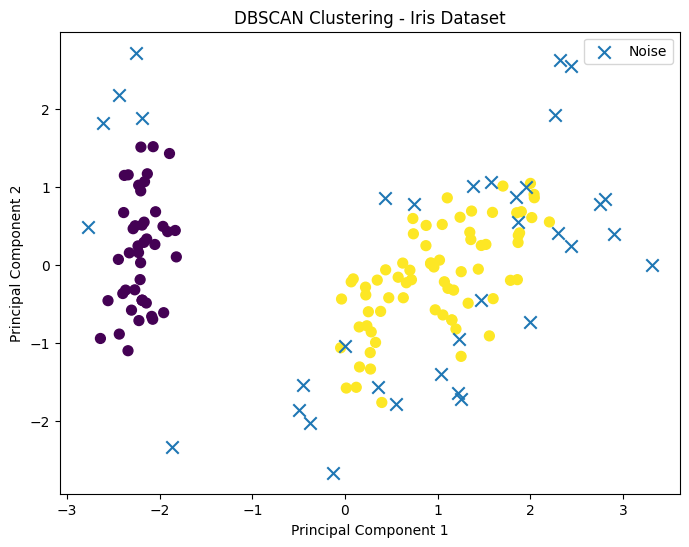


Cluster vs Species:
Species         Iris-setosa  Iris-versicolor  Iris-virginica
DBSCAN_Cluster                                              
-1                        6               11              18
 0                       44                0               0
 1                        0               39              32


In [1]:
# ============================================================
# DBSCAN CLUSTERING - IRIS DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("/content/Iris (2).csv")

print("Dataset Shape:", df.shape)

display(df.head())

# ------------------------------------------------------------
# 2. Select Features
# ------------------------------------------------------------

features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

X = df[features]

# ------------------------------------------------------------
# 3. Standardization
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# 4. DBSCAN
# ------------------------------------------------------------

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = labels

# ------------------------------------------------------------
# 5. Cluster Information
# ------------------------------------------------------------

number_of_clusters = len(
    set(labels)
) - (1 if -1 in labels else 0)

number_of_noise = np.sum(
    labels == -1
)

print("Number of Clusters:",
      number_of_clusters)

print("Number of Noise Points:",
      number_of_noise)

print("\nCluster Counts:")

print(
    df["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 6. Silhouette Score
# ------------------------------------------------------------

non_noise = labels != -1

if number_of_clusters >= 2:

    score = silhouette_score(
        X_scaled[non_noise],
        labels[non_noise]
    )

    print(
        "\nSilhouette Score:",
        round(score, 4)
    )

else:

    print(
        "\nSilhouette Score cannot be calculated."
    )

# ------------------------------------------------------------
# 7. PCA
# ------------------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# ------------------------------------------------------------
# 8. DBSCAN Visualization
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[non_noise,0],
    X_pca[non_noise,1],
    c=labels[non_noise],
    cmap="viridis",
    s=50
)

# Noise points

if np.any(~non_noise):

    plt.scatter(
        X_pca[~non_noise,0],
        X_pca[~non_noise,1],
        marker="x",
        s=80,
        label="Noise"
    )

    plt.legend()

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title(
    "DBSCAN Clustering - Iris Dataset"
)

plt.show()

# ------------------------------------------------------------
# 9. Compare with Species
# ------------------------------------------------------------

print("\nCluster vs Species:")

print(
    pd.crosstab(
        df["DBSCAN_Cluster"],
        df["Species"]
    )
)